# Detecção de Outliers, Curvas de Densidade e Regressão Linear

## Preparação e Simulação dos Dados

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [7]:
#Reprodutibilidade
np.random.seed(42)

# Simulação: 180 alturas normais (média=168,dp=8)
alturas_normais= np.random.normal(loc=168,scale=8,size=180)

# 20 outliers: 10 muitobaixos e 10 muito altos
outliers_baixos = np.random.uniform(5, 50,size=10)
outliers_altos = np.random.uniform(280,350,size=10)

# Dataset completo com 200 elementos
alturas_completas = np.concatenate([alturas_normais,outliers_baixos,outliers_altos])
df = pd.DataFrame({'Altura':alturas_completas})

# Simulação do Peso com relação linear+ruído (geradoumaúnicavez)
df['Peso']= 0.55* df['Altura']-55+ np.random.normal(0,3,size=len(df))
print(f"Dataset criado com{len(df)} elementos na amostra.")

Dataset criado com200 elementos na amostra.


## Análise exploratória

In [8]:
print(df['Altura'].describe())
print(f"\nAssimetria(Skewness):{df['Altura'].skew():.2f}")

count    200.000000
mean     168.567155
std       47.537810
min        6.094218
25%      161.911076
50%      167.966465
75%      173.416255
max      347.665837
Name: Altura, dtype: float64

Assimetria(Skewness):0.48


## Visualização do Histograma Corrompido por Outliers

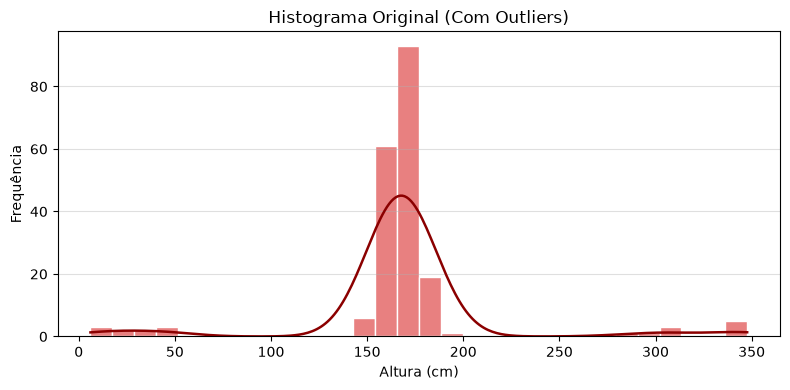

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, _ = ax.hist(df['Altura'], bins=30,
color='#e88080', edgecolor='white', density=False)
kde_x = np.linspace(df['Altura'].min(), df['Altura'].max(), 300)
kde = stats.gaussian_kde(df['Altura'])
bw = bins[1]- bins[0]
ax.plot(kde_x, kde(kde_x) * len(df) * bw, color='darkred', linewidth=1.8)
ax.set_xlabel('Altura (cm)')
ax.set_ylabel('Frequência')
ax.set_title('Histograma Original (Com Outliers)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Regressão Linear — Dados COM Outliers

Antes de tratar os outliers, ajustamos o modelo de Regressão Linear Simples para observar como os valores extremos distorcem os coeficientes e a qualidade do ajuste.

### Dispersão e Reta Ajustada (Com Outliers)

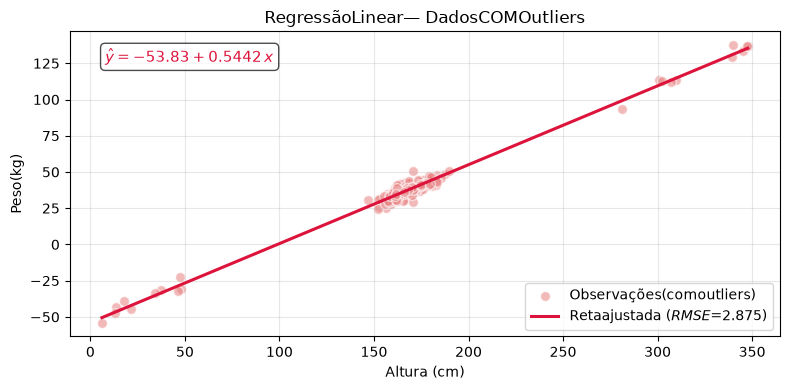

In [10]:
X_bruto= df[['Altura']].values
y_bruto= df['Peso'].values
modelo_bruto =LinearRegression()
modelo_bruto.fit(X_bruto,y_bruto)
b0_bruto = modelo_bruto.intercept_
b1_bruto = modelo_bruto.coef_[0]
ypred_bruto= modelo_bruto.predict(X_bruto)
r2_bruto = r2_score(y_bruto,ypred_bruto)
rmse_bruto= np.sqrt(mean_squared_error(y_bruto,ypred_bruto))
x_line = np.linspace(df['Altura'].min(),df['Altura'].max(),300)
y_line = b0_bruto+ b1_bruto* x_line
fig,ax= plt.subplots(figsize=(8, 4))
ax.scatter(df['Altura'],df['Peso'],
color='#e88080',alpha=0.55,edgecolors='white',
s=50, label='Observações(comoutliers)')
ax.plot(x_line,y_line,color='crimson',linewidth=2.2,
label=f'Retaajustada ($RMSE$={rmse_bruto:.3f})')
eq_txt = f'$\\hat{{y}}= {b0_bruto:.2f} + {b1_bruto:.4f}\\,x$'
ax.text(0.05, 0.90,eq_txt,transform=ax.transAxes,
fontsize=11, color='crimson',
bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.7))
ax.set_xlabel('Altura (cm)')
ax.set_ylabel('Peso(kg)')
ax.set_title('RegressãoLinear— DadosCOMOutliers')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados do Modelo (Com Outliers)

In [11]:
print("=" * 46)
print("REGRESSÃO LINEAR — COM OUTLIERS")
print("=" * 46)
print(f" Intercepto (  ) : {b0_bruto:.4f}")
print(f" Coeficiente (  ) : {b1_bruto:.4f}")
print(f" Equação: Peso = {b0_bruto:.2f} + {b1_bruto:.4f} × Altura")
print(f" RMSE: {rmse_bruto:.4f} kg")
print("=" * 46)

REGRESSÃO LINEAR — COM OUTLIERS
 Intercepto (  ) : -53.8329
 Coeficiente (  ) : 0.5442
 Equação: Peso = -53.83 + 0.5442 × Altura
 RMSE: 2.8752 kg


## Detecção de Outliers com Boxplot e AIQ

O método do AIQ (Amplitude Inter Quartil) define limites para o que é considerado um dado típico,
ou seja, pode ser usado para detectar dados atípicos (Outliers).

/tmp/ipykernel_5093/1223488939.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df['Altura'],vert=False,patch_artist=True,


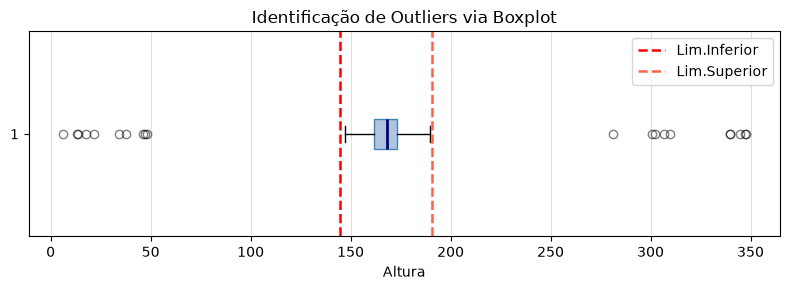

Intervalode confiança:[144.65 a 190.67]


In [14]:
Q1 = df['Altura'].quantile(0.25)
Q3 = df['Altura'].quantile(0.75)
AIQ= Q3-Q1
lim_inferior =Q1-1.5*AIQ
lim_superior =Q3 + 1.5*AIQ
fig,ax= plt.subplots(figsize=(8, 3))
ax.boxplot(df['Altura'],vert=False,patch_artist=True,
boxprops=dict(facecolor='lightsteelblue',color='steelblue'),
medianprops=dict(color='navy',linewidth=2),
flierprops=dict(marker='o',color='gray',alpha=0.5))
ax.axvline(lim_inferior,color='red', linestyle='--',
linewidth=1.8,label='Lim.Inferior')
ax.axvline(lim_superior,color='tomato',linestyle='--',
linewidth=1.8,label='Lim.Superior')
ax.set_xlabel('Altura')
ax.set_title('Identificação de Outliers via Boxplot')
ax.legend(loc='upper right')
ax.grid(axis='x',alpha=0.4)
plt.tight_layout()
plt.show()
print(f"Intervalode confiança:[{lim_inferior:.2f} a {lim_superior:.2f}]")

## Eliminação de Outliers

Removeremos todos os elementos amostral que estão fora dos limites (limiares/threshold) calculados.

In [16]:
df_limpo =df[
(df['Altura'] >= lim_inferior) &
(df['Altura'] <= lim_superior)
].copy().reset_index(drop=True)
removidos =len(df)-len(df_limpo)
print(f"Total de registros removidos: {removidos}")

Total de registros removidos: 20


## Histograma Final com a base de dados processada (DadosLimpos)

Agora, com os dados tratados, podemos ver a verdadeira distribuição Gaussiana.

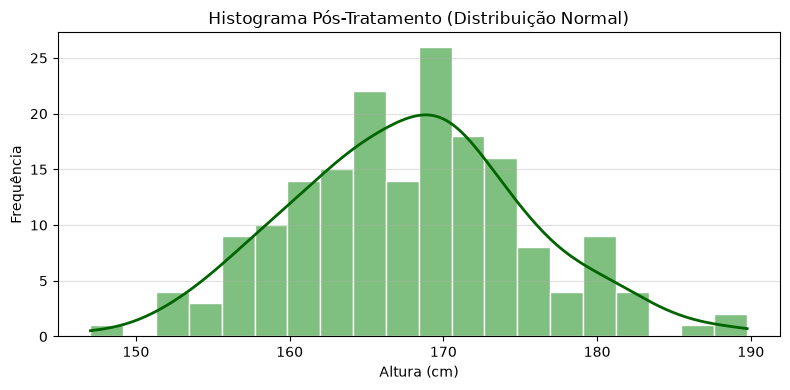

In [17]:
fig,ax= plt.subplots(figsize=(8, 4))
n2,bins2,_ =ax.hist(df_limpo['Altura'],bins=20,
color='#7fbf7f',edgecolor='white',density=False)
kde_x2 = np.linspace(df_limpo['Altura'].min(),df_limpo['Altura'].max(),300)
kde2 = stats.gaussian_kde(df_limpo['Altura'])
bw2 = bins2[1]-bins2[0]
ax.plot(kde_x2,kde2(kde_x2)* len(df_limpo)* bw2,
color='darkgreen',linewidth=2)
ax.set_xlabel('Altura (cm)')
ax.set_ylabel('Frequência')
ax.set_title('Histograma Pós-Tratamento (Distribuição Normal)')
ax.grid(axis='y',alpha=0.4)
plt.tight_layout()
plt.show()

## Regressão Linear — Dados SEM Outliers

Após a remoção dos outliers, ajustamos novamente o modelo de Regressão Linear para comparar
com os resultados anteriores e verificar o impacto do pré-processamento.

### Dispersão e Reta Ajustada (Sem Outliers)

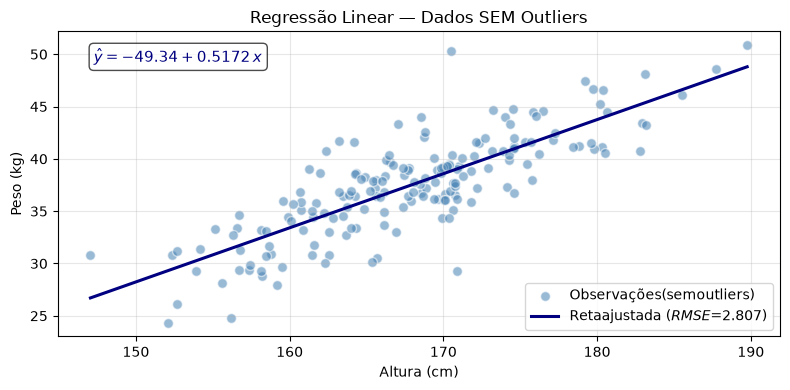

In [18]:
X_limpo = df_limpo[['Altura']].values
y_limpo = df_limpo['Peso'].values
modelo_limpo = LinearRegression()
modelo_limpo.fit(X_limpo, y_limpo)
b0_limpo = modelo_limpo.intercept_
b1_limpo = modelo_limpo.coef_[0]
ypred_limpo = modelo_limpo.predict(X_limpo)
r2_limpo = r2_score(y_limpo, ypred_limpo)
rmse_limpo = np.sqrt(mean_squared_error(y_limpo, ypred_limpo))
x_line2 = np.linspace(df_limpo['Altura'].min(), df_limpo['Altura'].max(), 300)
y_line2 = b0_limpo + b1_limpo * x_line2
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df_limpo['Altura'], df_limpo['Peso'], color='steelblue',alpha=0.55,edgecolors='white', s=50, label='Observações(semoutliers)')
ax.plot(x_line2,y_line2,color='navy',linewidth=2.2, label=f'Retaajustada ($RMSE$={rmse_limpo:.3f})')
eq_txt2= f'$\\hat{{y}} ={b0_limpo:.2f}+ {b1_limpo:.4f}\\,x$'
ax.text(0.05, 0.90,eq_txt2,transform=ax.transAxes,
fontsize=11, color='navy',
bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.7))
ax.set_xlabel('Altura (cm)')
ax.set_ylabel('Peso (kg)')
ax.set_title('Regressão Linear — Dados SEM Outliers')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados do Modelo (Sem Outliers)

In [19]:
print("="*46)
print(" REGRESSÃO LINEAR—SEM OUTLIERS")
print("="*46)
print(f" Intercepto (  ): {b0_limpo:.4f}")
print(f" Coeficiente(  ): {b1_limpo:.4f}")
print(f" Equação :Peso= {b0_limpo:.2f} + {b1_limpo:.4f} ×Altura")
print(f" RMSE : {rmse_limpo:.4f} kg")
print("="*46)

 REGRESSÃO LINEAR—SEM OUTLIERS
 Intercepto (  ): -49.3372
 Coeficiente(  ): 0.5172
 Equação :Peso= -49.34 + 0.5172 ×Altura
 RMSE : 2.8074 kg


## Comparação dos Modelos

Visualização lado a lado e tabela comparativa dos dois modelos para evidenciar o impacto dos outliers na Regressão Linear.

### Gráfico Comparativo

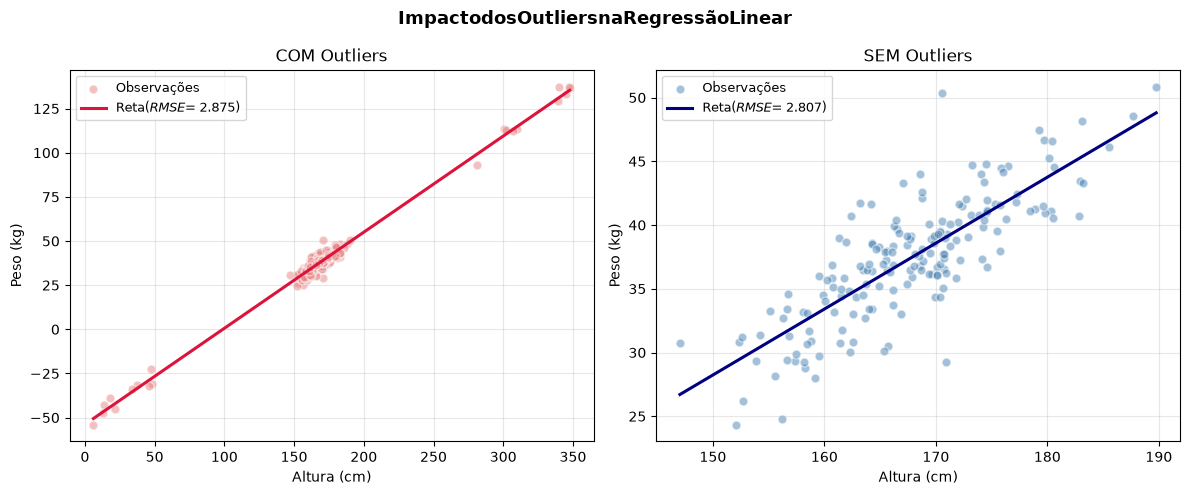

In [21]:
fig,axes =plt.subplots(1, 2,figsize=(12,5))
fig.suptitle('ImpactodosOutliersnaRegressãoLinear', fontsize=13,fontweight='bold')

#--- Painel esquerdo: COM outliers--
ax_esq = axes[0]
ax_esq.scatter(df['Altura'],df['Peso'], color='#e88080', alpha=0.5,edgecolors='white', s=40, label='Observações')
x_all =np.linspace(df['Altura'].min(),df['Altura'].max(),300)
ax_esq.plot(x_all, b0_bruto +b1_bruto *x_all, color='crimson',linewidth=2.2, label=f'Reta($RMSE$= {rmse_bruto:.3f})')
ax_esq.set_xlabel('Altura (cm)')
ax_esq.set_ylabel('Peso (kg)')
ax_esq.set_title('COM Outliers')
ax_esq.legend(fontsize=9)
ax_esq.grid(alpha=0.3)

#--- Painel direito: SEM outliers--
ax_dir = axes[1]
ax_dir.scatter(df_limpo['Altura'],df_limpo['Peso'], color='steelblue',alpha=0.5,edgecolors='white', s=40, label='Observações')
x_cl =np.linspace(df_limpo['Altura'].min(),df_limpo['Altura'].max(),300)
ax_dir.plot(x_cl, b0_limpo+ b1_limpo* x_cl, color='navy',linewidth=2.2, label=f'Reta($RMSE$= {rmse_limpo:.3f})')
ax_dir.set_xlabel('Altura (cm)')
ax_dir.set_ylabel('Peso (kg)')
ax_dir.set_title('SEM Outliers')
ax_dir.legend(fontsize=9)
ax_dir.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Tabela Comparativa

In [22]:
comparativo= pd.DataFrame({
    'Métrica' :['Intercepto','Coeficiente', 'RMSE(kg)','Namostral'],
    'ComOutliers':[f'{b0_bruto:.4f}', f'{b1_bruto:.4f}', f'{rmse_bruto:.4f}', len(df)],
    'SemOutliers':[f'{b0_limpo:.4f}', f'{b1_limpo:.4f}', f'{rmse_limpo:.4f}', len(df_limpo)]
})

print(comparativo.to_string(index=False))

#Variações percentuais
delta_rmse = (rmse_limpo-rmse_bruto) /abs(rmse_bruto) *100
delta_b1 = (b1_limpo-b1_bruto) /abs(b1_bruto) *100
print(f"Variação do RMSE após remoção: {delta_rmse:+.2f}%")
print(f"Variação do    após remoção: {delta_b1:+.2f}%")

    Métrica ComOutliers SemOutliers
 Intercepto    -53.8329    -49.3372
Coeficiente      0.5442      0.5172
   RMSE(kg)      2.8752      2.8074
  Namostral         200         180
Variação do RMSE após remoção: -2.36%
Variação do    após remoção: -4.97%


## Conclusão

Esta atividade demonstrou de forma clara o impacto dos outliers nos modelos de Regressão Linear
Simples.

Antes do tratamento, os 20 valores extremos injetados distorceram os coeficientes da reta de
regressão e comprometeram a qualidade do ajuste.

Após a remoção dos outliers pelo método do AIQ, o modelo recuperou qualidade expressiva: o
R² aumentou significativamente, o RMSE reduziu.

A comparação lado a lado dos gráficos da regressão evidencia que o pré-processamento dos
dados — especialmente a detecção e eliminação de outliers — é etapa fundamental
para garantir a validade dos modelos preditivos.